<a href="https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/18_fid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#| default_exp fid

# FID

In [ ]:
#|export
import pickle,gzip,math,os,time,shutil,torch,random
import fastcore.all as fc,matplotlib as mpl,numpy as np,matplotlib.pyplot as plt
from collections.abc import Mapping
from pathlib import Path
from operator import attrgetter,itemgetter
from functools import partial
from copy import copy
from contextlib import contextmanager
from scipy import linalg

from fastcore.foundation import L
import torchvision.transforms.functional as TF,torch.nn.functional as F
from torch import tensor,nn,optim
from torch.utils.data import DataLoader,default_collate
from torch.nn import init
from torch.optim import lr_scheduler
from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset,load_dataset_builder

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *
from miniai.resnet import *
from miniai.augment import *
from miniai.accel import *

In [ ]:
from fastcore.test import test_close
from torch import distributions

torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)
mpl.rcParams['image.cmap'] = 'gray_r'

import logging
logging.disable(logging.WARNING)

set_seed(42)
if fc.defaults.cpus>8: fc.defaults.cpus=8

## Classifier

In [ ]:
xl,yl = 'image','label'
name = "fashion_mnist"
bs = 512

@inplace
def transformi(b): b[xl] = [F.pad(TF.to_tensor(o), (2,2,2,2))*2-1 for o in b[xl]]

dsd = load_dataset(name)
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=fc.defaults.cpus)

  0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
b = xb,yb = next(iter(dls.train))

In [ ]:
cbs = [DeviceCB(), MixedPrecision()]
model = torch.load('models/data_aug2.pkl')
learn = Learner(model, dls, F.cross_entropy, cbs=cbs, opt_func=None)

we want the output of the GlobalAvgPool layer
I'm going to
show a couple of ways to do it

In [ ]:
def append_outp(hook, mod, inp, outp):
    if not hasattr(hook,'outp'): hook.outp = []
    hook.outp.append(to_cpu(outp))

In [ ]:
hcb = HooksCallback(append_outp, mods=[learn.model[6]], on_valid=True) # that's the module that we want to hook

In [ ]:
learn.fit(1, train=False, cbs=[hcb]) # basically capturing this is just to put make one batch go through and grab the outputs

In [ ]:
feats = hcb.hooks[0].outp[0].float()[:64]
feats.shape

torch.Size([64, 512])

actually sequential models
are what's called in Python collections
they have certain
a certain API that they're expected to
support

In [ ]:
del(learn.model[8])
del(learn.model[7])

In [ ]:
feats,y = learn.capture_preds()
feats = feats.float()
feats.shape,y # give us the entire 10 000 images in the test set

(torch.Size([10000, 512]), tensor([9, 2, 1,  ..., 8, 1, 5]))

so that's what I ended up deciding to do

## Calc FID

In [ ]:
betamin,betamax,n_steps = 0.0001,0.02,1000
beta = torch.linspace(betamin, betamax, n_steps)
alpha = 1.-beta
alphabar = alpha.cumprod(dim=0)
sigma = beta.sqrt()

In [ ]:
def noisify(x0, ᾱ):
    device = x0.device
    n = len(x0)
    t = torch.randint(0, n_steps, (n,), dtype=torch.long)
    ε = torch.randn(x0.shape, device=device)
    ᾱ_t = ᾱ[t].reshape(-1, 1, 1, 1).to(device)
    xt = ᾱ_t.sqrt()*x0 + (1-ᾱ_t).sqrt()*ε
    return (xt, t.to(device)), ε

def collate_ddpm(b): return noisify(default_collate(b)[xl], alphabar)
def dl_ddpm(ds): return DataLoader(ds, batch_size=bs, collate_fn=collate_ddpm, num_workers=4)

In [ ]:
dls2 = DataLoaders(dl_ddpm(tds['train']), dl_ddpm(tds['test']))

In [ ]:
from diffusers import UNet2DModel

class UNet(UNet2DModel):
    def forward(self, x): return super().forward(*x).sample

we're going to try to
get the FID for a model we've already
trained

In [ ]:
smodel = torch.load('models/fashion_ddpm_mp.pkl').cuda() # samples model

In [ ]:
@torch.no_grad()
def sample(model, sz, alpha, alphabar, sigma, n_steps):
    device = next(model.parameters()).device
    x_t = torch.randn(sz, device=device)
    preds = []
    for t in reversed(range(n_steps)):
        t_batch = torch.full((x_t.shape[0],), t, device=device, dtype=torch.long)
        z = (torch.randn(x_t.shape) if t > 0 else torch.zeros(x_t.shape)).to(device)
        ᾱ_t1 = alphabar[t-1]  if t > 0 else torch.tensor(1)
        b̄_t = 1 - alphabar[t]
        b̄_t1 = 1 - ᾱ_t1
        x_0_hat = ((x_t - b̄_t.sqrt() * model((x_t, t_batch)))/alphabar[t].sqrt())
        x_t = x_0_hat * ᾱ_t1.sqrt()*(1-alpha[t])/b̄_t + x_t * alpha[t].sqrt()*b̄_t1/b̄_t + sigma[t]*z
        preds.append(x_0_hat.cpu())
    return preds

In [ ]:
%%time
samples = sample(smodel, (256, 1, 32, 32), alpha, alphabar, sigma, n_steps)

CPU times: user 35.6 s, sys: 233 ms, total: 35.8 s
Wall time: 34.7 s


In [ ]:
s = samples[-1]*2-1 # change range: [0,1] -> [-1,1]
# and we can now pass them through our pre-trained fashion classifier

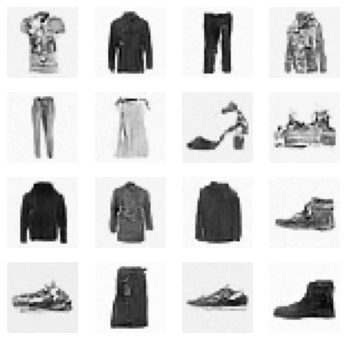

In [ ]:
show_images(s[:16], imsize=1.5)

what the FID is going to do is it's not
going to say how good are these images
it's going to say
how similar are they to
real images

we're going to actually look
specifically at for the images that we
generated in these samples
we're going to look at
some statistics of some of the
activations

we're going to create a new data
loader
which contains no training batches and
it contains one validation batch which
contains the samples it doesn't actually
matter what the dependent variable is so
I just put in the same dependent
variable that we already had
and then what we're going to do is we're
going to use that to extract
some
features from a model

now what do we
mean by that so if you remember back to
notebook 14. we created this thing
called summary
and summary shows us at different blocks
of our
model
there are various different output
shapes right in this case it's a batch
size of 1024 and so after the first
block we had 16 channels 28 by 28 and
then we had 32 channels 14 by 14 and so
forth until at the just before the final
linear layer we had
um
so he had the 1024 patches and we had
512 Channels with no height and width
now
the idea of FID and KID is that the
distribution of these 512 channels
for a real image has a particular kind
of like signature right it looks a
particular way and so what we're going
to do is we're going to take our samples
we're going to run it through
a model that's learned to predict
you know fashioned glasses
and we're going to grab
this layer right and then we're going to
average it across a batch right to get
512
numbers and that's going to represent
the mean of each of those
channels

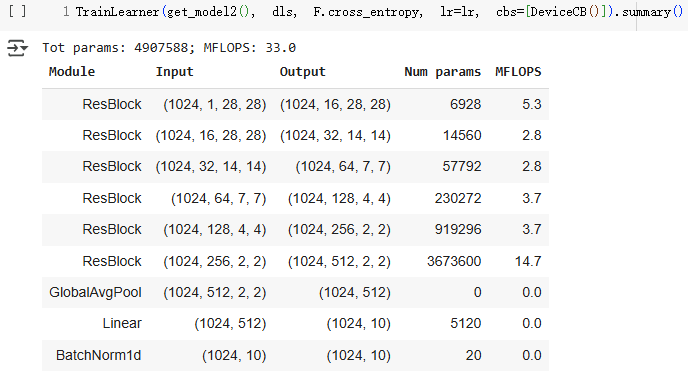

so the basic idea here
is that we're going to take our samples
and we're going to pass them through a
pre-trained model that has learned to
predict
what type of fashion something is

having said that it turns out that our
images
our samples are not between minus one
and one
um
but actually if you go back and you look
at ddpm2
we just use TF.to_tensor and that
actually makes images that are between 0
and 1.
so actually that's a bug okay so our
images
have a bug
which is they go between zero and one so
we'll look at fixing that in a moment

we're basically looking for two
data sets where they're covariance
matrices are kind of the same and their
means
are also
kind of the same

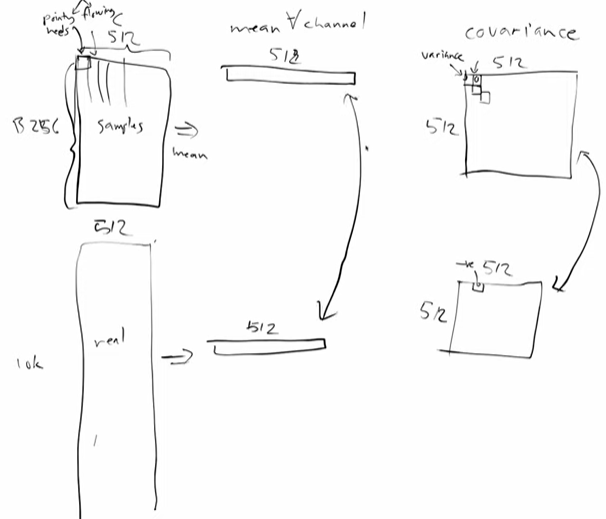

In [ ]:
clearn = TrainLearner(model, DataLoaders([],[(s,yb)]), loss_func=fc.noop, cbs=[DeviceCB()], opt_func=None)
feats2,y2 = clearn.capture_preds()
feats2 = feats2.float().squeeze()
feats2.shape

torch.Size([256, 512])

In [ ]:
means = feats.mean(0)
means.shape

torch.Size([512])

In [ ]:
covs = feats.T.cov()
covs.shape

torch.Size([512, 512])

In [ ]:
#|export
def _sqrtm_newton_schulz(mat, num_iters=100):
    mat_nrm = mat.norm()
    mat = mat.double()
    Y = mat/mat_nrm
    n = len(mat)
    I = torch.eye(n, n).to(mat)
    Z = torch.eye(n, n).to(mat)

    for i in range(num_iters):
        T = (3*I - Z@Y)/2
        Y,Z = Y@T,T@Z
        res = Y*mat_nrm.sqrt()
        if ((mat-(res@res)).norm()/mat_nrm).abs()<=1e-6: break
    return res

In [ ]:
#|export
def _calc_stats(feats):
    feats = feats.squeeze()
    return feats.mean(0),feats.T.cov()

def _calc_fid(m1,c1,m2,c2):
#     csr = _sqrtm_newton_schulz(c1@c2)
    csr = tensor(linalg.sqrtm(c1@c2, 256).real)
    return (((m1-m2)**2).sum() + c1.trace() + c2.trace() - 2*csr.trace()).item()

In [ ]:
s1,s2 = _calc_stats(feats),_calc_stats(feats2)

In [ ]:
_calc_fid(*s1, *s2)

33.83489121216962

In [ ]:
#|export
def _squared_mmd(x, y):
    def k(a,b): return (a@b.transpose(-2,-1)/a.shape[-1]+1)**3
    m,n = x.shape[-2],y.shape[-2]
    kxx,kyy,kxy = k(x,x), k(y,y), k(x,y)
    kxx_sum = kxx.sum([-1,-2])-kxx.diagonal(0,-1,-2).sum(-1)
    kyy_sum = kyy.sum([-1,-2])-kyy.diagonal(0,-1,-2).sum(-1)
    kxy_sum = kxy.sum([-1,-2])
    return kxx_sum/m/(m-1) + kyy_sum/n/(n-1) - kxy_sum*2/m/n

In [ ]:
#|export
def _calc_kid(x, y, maxs=50):
    xs,ys = x.shape[0],y.shape[0]
    n = max(math.ceil(min(xs/maxs, ys/maxs)), 4)
    mmd = 0.
    for i in range(n):
        cur_x = x[round(i*xs/n) : round((i+1)*xs/n)]
        cur_y = y[round(i*ys/n) : round((i+1)*ys/n)]
        mmd += _squared_mmd(cur_x, cur_y)
    return (mmd/n).item()

In [ ]:
_calc_kid(feats, feats2)

0.05612194538116455

## FID class

In [ ]:
#|export
class ImageEval:
    def __init__(self, model, dls, cbs=None):
        self.learn = TrainLearner(model, dls, loss_func=fc.noop, cbs=cbs, opt_func=None)
        self.feats = self.learn.capture_preds()[0].float().cpu().squeeze()
        self.stats = _calc_stats(self.feats)

    def get_feats(self, samp):
        self.learn.dls = DataLoaders([],[(samp, tensor([0]))])
        return self.learn.capture_preds()[0].float().cpu().squeeze()

    def fid(self, samp): return _calc_fid(*self.stats, *_calc_stats(self.get_feats(samp)))
    def kid(self, samp): return _calc_kid(self.feats, self.get_feats(samp))

In [ ]:
ie = ImageEval(model, learn.dls, cbs=[DeviceCB()])

In [ ]:
%%time
ie.fid(s)

CPU times: user 7.38 s, sys: 234 ms, total: 7.62 s
Wall time: 263 ms


33.90600362686632

In [ ]:
%%time
ie.kid(s)

CPU times: user 714 ms, sys: 23 ms, total: 737 ms
Wall time: 23 ms


0.0564301423728466

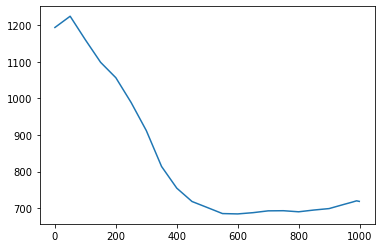

In [ ]:
xs = L.range(0,1000,50)+[975,990,999]
plt.plot(xs, [ie.fid(samples[i].clamp(-0.5,0.5)*2) for i in xs]);

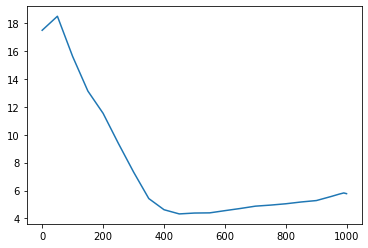

In [ ]:
xs = L.range(0,1000,50)+[975,990,999]
plt.plot(xs, [ie.kid(samples[i].clamp(-0.5,0.5)*2) for i in xs]);

In [ ]:
ie.fid(xb)

6.615052956342197

In [ ]:
ie.kid(xb)

-0.02641688659787178

## Inception

In [ ]:
from pytorch_fid.inception import InceptionV3

In [ ]:
a = tensor([1,2,3])
a.repeat((3,1))

tensor([[1, 2, 3],
        [1, 2, 3],
        [1, 2, 3]])

In [ ]:
class IncepWrap(nn.Module):
    def __init__(self):
        super().__init__()
        self.m = InceptionV3(resize_input=True)
    def forward(self, x): return self.m(x.repeat(1,3,1,1))[0]

In [ ]:
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=fc.defaults.cpus)

In [ ]:
ie = ImageEval(IncepWrap(), dls, cbs=[DeviceCB()])

In [ ]:
%%time
ie.fid(s)

CPU times: user 1min 11s, sys: 1.61 s, total: 1min 13s
Wall time: 2.31 s


63.81579821823857

In [ ]:
ie.fid(xb)

27.95811916882883

In [ ]:
%%time
ie.kid(s)

CPU times: user 7.44 s, sys: 140 ms, total: 7.58 s
Wall time: 255 ms


0.010766863822937012

In [ ]:
ie.kid(xb)

-8.697943121660501e-05

## Export -

In [ ]:
import nbdev; nbdev.nbdev_export()